# 1. IMPORT LIBRARY

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

sns.set_theme(style="whitegrid")

# 2. DATA LOADING

In [135]:
df = pd.read_csv(
    "Data/Raw_Responses/raw_google_form_export.csv",
    skiprows=[1],
    encoding="latin-1" 
)
df.head()

,Timestamp,1. Age\nExample: 23 [Restricted to 19ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½,2. Gender\nExample: Male,3. Study_Hours (per day) \nExample: 3,4. Class_Attendance (%) \nExample: 85,5. Tuition (Private Coaching) \nExample: Yes,6. Exam_Frequency (per semester) \nExample: 4,7. Assignment_Load (1ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½,8. Sleep_Hours (per day) \nExample: 6,9. Physical_Exercise (hours per week) \nExample: 2,10. Social_Media_Use (hours per day) \nExample: 3,11. Screen_Time (hours per day) \nExample: 6,12. Family_Income_Level \nExample: Middle,13. Peer_Pressure (1ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½,14. Family_Support (1ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½,15. Anxiety_Level (1ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½,16. University_Type \nExample: Public University,17. Stress_Score (1ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï,18. Stress_Level \nExample: Moderate
0,2025/10/01 12:36:28 AM GMT+6,24,Female,8,43,Yes,6,8,5,Yes,6,8,Medium,3,7,8,National University,22,High
1,2025/10/01 01:12:57 AM GMT+6,21,Female,4,56,Yes,3,6,5,Yes,7,9,Low,2,5,3,Private University,16,Medium
2,2025/10/01 01:49:26 AM GMT+6,23,Female,4,46,No,8,6,8,No,5,6,Medium,8,6,5,Private University,16,Medium
3,2025/10/01 02:25:55 AM GMT+6,20,Male,8,46,No,5,1,6,Yes,0,7,Medium,5,6,2,National University,1,Low
4,2025/10/01 03:02:23 AM GMT+6,19,Male,2,95,No,5,2,7,No,3,6,Low,2,6,1,National University,4,Low


# 3. DATA CLEANING

In [136]:
df.columns = [
    "Timestamp","Age","Gender","Study_Hours","Class_Attendance",
    "Tuition","Exam_Frequency","Assignment_Load",
    "Sleep_Hours","Physical_Exercise","Social_Media_Use",
    "Screen_Time","Family_Income_Level","Peer_Pressure",
    "Family_Support","Anxiety_Level","University_Type",
    "Stress_Score","Stress_Level"
]

print(df.head())

                      Timestamp  Age  Gender  Study_Hours  Class_Attendance  \
0  2025/10/01 12:36:28 AM GMT+6   24  Female            8                43   
1  2025/10/01 01:12:57 AM GMT+6   21  Female            4                56   
2  2025/10/01 01:49:26 AM GMT+6   23  Female            4                46   
3  2025/10/01 02:25:55 AM GMT+6   20    Male            8                46   
4  2025/10/01 03:02:23 AM GMT+6   19    Male            2                95   

  Tuition  Exam_Frequency  Assignment_Load  Sleep_Hours Physical_Exercise  \
0     Yes               6                8            5               Yes   
1     Yes               3                6            5               Yes   
2      No               8                6            8                No   
3      No               5                1            6               Yes   
4      No               5                2            7                No   

   Social_Media_Use  Screen_Time Family_Income_Level  Peer_Pre

In [137]:
# Drop kolom tidak penting
df = df.drop(columns=["Timestamp"])

In [138]:
# Convert numeric
num_cols = [
    "Age","Study_Hours","Class_Attendance","Exam_Frequency",
    "Assignment_Load","Sleep_Hours","Social_Media_Use",
    "Screen_Time","Peer_Pressure","Family_Support",
    "Anxiety_Level","Stress_Score"
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [139]:
# Handle invalid negative values
num_cols = df.select_dtypes(include="number").columns

df[num_cols] = df[num_cols].mask(df[num_cols] < 0)

In [140]:
# Clean categorical
cat_cols = ["Gender","Tuition","University_Type","Family_Income_Level","Stress_Level"]

for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

In [141]:
# Filter umur
df = df[(df["Age"] >= 19) & (df["Age"] <= 24)]

# Drop leakage
df = df.drop(columns=["Stress_Score","Anxiety_Level"])

In [142]:
df.head()

,Age,Gender,Study_Hours,Class_Attendance,Tuition,Exam_Frequency,Assignment_Load,Sleep_Hours,Physical_Exercise,Social_Media_Use,Screen_Time,Family_Income_Level,Peer_Pressure,Family_Support,University_Type,Stress_Level
0,24,Female,8,43,Yes,6,8,5,Yes,6,8,Medium,3,7,National University,High
1,21,Female,4,56,Yes,3,6,5,Yes,7,9,Low,2,5,Private University,Medium
2,23,Female,4,46,No,8,6,8,No,5,6,Medium,8,6,Private University,Medium
3,20,Male,8,46,No,5,1,6,Yes,0,7,Medium,5,6,National University,Low
4,19,Male,2,95,No,5,2,7,No,3,6,Low,2,6,National University,Low


In [143]:
# Range Validation
df = df[
    (df["Age"].between(19, 24)) &
    (df["Class_Attendance"].between(0, 100)) &
    (df["Exam_Frequency"].between(1, 10)) &
    (df["Assignment_Load"].between(1, 10)) &
    (df["Peer_Pressure"].between(1, 10)) &
    (df["Family_Support"].between(1, 10))
]

In [144]:
binary_map = {
    "Yes": 1,
    "No": 0
}

df["Physical_Exercise"] = df["Physical_Exercise"].map(binary_map)
df["Tuition"] = df["Tuition"].map(binary_map)
df["Tuition"] = df["Tuition"].astype("category")

In [145]:
print(df["Physical_Exercise"].unique())
print(df["Tuition"].unique())

[1 0]
[1, 0]
Categories (2, int64): [0, 1]


In [146]:
from pandas.api.types import CategoricalDtype

income_order = CategoricalDtype(
    categories=["Low", "Medium", "High"],
    ordered=True
)

df["Family_Income_Level"] = df["Family_Income_Level"].astype(income_order)

In [147]:
print(df["Tuition"].dtype)
print(df["Family_Income_Level"].dtype)
print(df["Family_Income_Level"].cat.categories)

category
category
Index(['Low', 'Medium', 'High'], dtype='object')


In [148]:
# Drop missing & duplicate
df = df.dropna()
df = df.drop_duplicates()

In [149]:
print("Shape:", df.shape)
print("\nMissing:\n", df.isnull().sum())
print("\nNegative:\n", (df.select_dtypes(include="number") < 0).sum())
print("\nDuplicate:", df.duplicated().sum())
print("\nDtypes:\n", df.dtypes)

Shape: (2999, 16)

Missing:
 Age                    0
Gender                 0
Study_Hours            0
Class_Attendance       0
Tuition                0
Exam_Frequency         0
Assignment_Load        0
Sleep_Hours            0
Physical_Exercise      0
Social_Media_Use       0
Screen_Time            0
Family_Income_Level    0
Peer_Pressure          0
Family_Support         0
University_Type        0
Stress_Level           0
dtype: int64

Negative:
 Age                  0
Study_Hours          0
Class_Attendance     0
Exam_Frequency       0
Assignment_Load      0
Sleep_Hours          0
Physical_Exercise    0
Social_Media_Use     0
Screen_Time          0
Peer_Pressure        0
Family_Support       0
dtype: int64

Duplicate: 0

Dtypes:
 Age                       int64
Gender                   object
Study_Hours               int64
Class_Attendance          int64
Tuition                category
Exam_Frequency            int64
Assignment_Load           int64
Sleep_Hours               int64


In [150]:
df.describe()

,Age,Study_Hours,Class_Attendance,Exam_Frequency,Assignment_Load,Sleep_Hours,Physical_Exercise,Social_Media_Use,Screen_Time,Peer_Pressure,Family_Support
count,2999.000000,2999.000000,2999.000000,2999.000000,2999.000000,2999.000000,2999.000000,2999.000000,2999.000000,2999.000000,2999.000000
mean,21.516506,4.487162,68.871624,5.025008,4.996332,6.519173,0.482828,3.486162,5.917306,4.983661,5.027676
std,1.705359,2.857947,17.445441,2.592204,2.595023,1.687636,0.499788,2.288642,3.185163,2.567839,2.568261
min,19.000000,0.000000,40.000000,1.000000,1.000000,4.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,20.000000,2.000000,54.000000,3.000000,3.000000,5.000000,0.000000,2.000000,3.000000,3.000000,3.000000
50%,21.000000,4.000000,69.000000,5.000000,5.000000,7.000000,0.000000,3.000000,6.000000,5.000000,5.000000
75%,23.000000,7.000000,84.000000,7.000000,7.000000,8.000000,1.000000,5.000000,9.000000,7.000000,7.000000
max,24.000000,9.000000,99.000000,9.000000,9.000000,9.000000,1.000000,7.000000,11.000000,9.000000,9.000000


# 4. DATA UNDERSTANDING

In [151]:
print(df.info())
print(df.describe())
print("Duplicate:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2999 entries, 0 to 2998
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Age                  2999 non-null   int64   
 1   Gender               2999 non-null   object  
 2   Study_Hours          2999 non-null   int64   
 3   Class_Attendance     2999 non-null   int64   
 4   Tuition              2999 non-null   category
 5   Exam_Frequency       2999 non-null   int64   
 6   Assignment_Load      2999 non-null   int64   
 7   Sleep_Hours          2999 non-null   int64   
 8   Physical_Exercise    2999 non-null   int64   
 9   Social_Media_Use     2999 non-null   int64   
 10  Screen_Time          2999 non-null   int64   
 11  Family_Income_Level  2999 non-null   category
 12  Peer_Pressure        2999 non-null   int64   
 13  Family_Support       2999 non-null   int64   
 14  University_Type      2999 non-null   object  
 15  Stress_Level         

In [152]:
#DISTRIBUSI TARGET
df["Stress_Level"].value_counts()

Stress_Level
Medium    1430
Low       1243
High       326
Name: count, dtype: int64

In [153]:
df["Stress_Level"].value_counts(normalize=True) * 100

Stress_Level
Medium    47.682561
Low       41.447149
High      10.870290
Name: proportion, dtype: float64

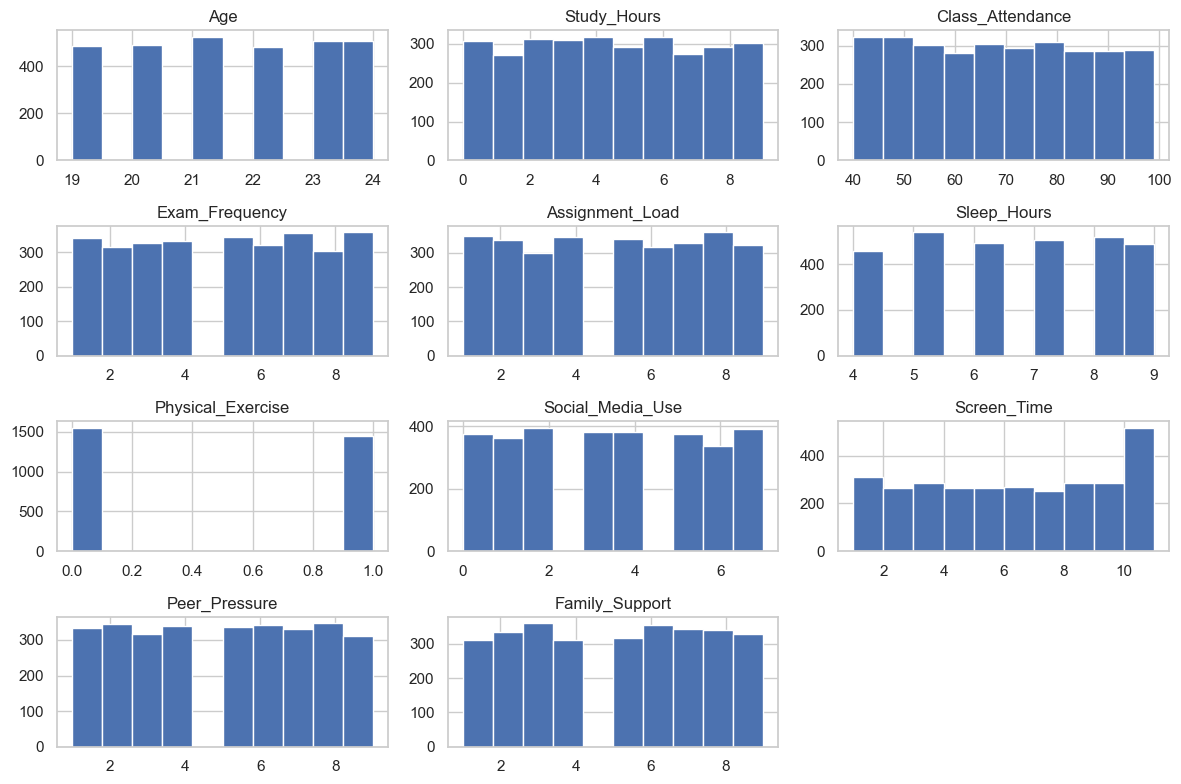

In [154]:
#CEK DISTRIBUSI NUMERIK
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

In [155]:
#CEK CATEGORICAL DISTRIBUTION
for col in ["Gender", "University_Type", "Family_Income_Level", "Tuition"]:
    print(f"\n{col}")
    print(df[col].value_counts())


Gender
Gender
Female    1538
Male      1461
Name: count, dtype: int64

University_Type
University_Type
Public University      1003
National University     999
Private University      997
Name: count, dtype: int64

Family_Income_Level
Family_Income_Level
Medium    1333
Low       1058
High       608
Name: count, dtype: int64

Tuition
Tuition
0    1544
1    1455
Name: count, dtype: int64


In [156]:
#CEK KORELASI
df.corr(numeric_only=True)["Screen_Time"].sort_values(ascending=False)

Screen_Time          1.000000
Class_Attendance     0.029559
Physical_Exercise    0.019223
Sleep_Hours          0.018414
Exam_Frequency       0.014956
Social_Media_Use     0.014897
Assignment_Load      0.004322
Age                 -0.012583
Peer_Pressure       -0.026959
Family_Support      -0.034991
Study_Hours         -0.035367
Name: Screen_Time, dtype: float64

In [157]:
#GROUP ANALYSIS
df.groupby("Stress_Level")[[
    "Sleep_Hours",
    "Screen_Time",
    "Study_Hours",
    "Peer_Pressure"
]].mean().round(2)

,Sleep_Hours,Screen_Time,Study_Hours,Peer_Pressure
Stress_Level,,,,
High,5.88,8.65,4.29,4.83
Low,6.90,4.37,4.51,5.00
Medium,6.34,6.64,4.51,5.01


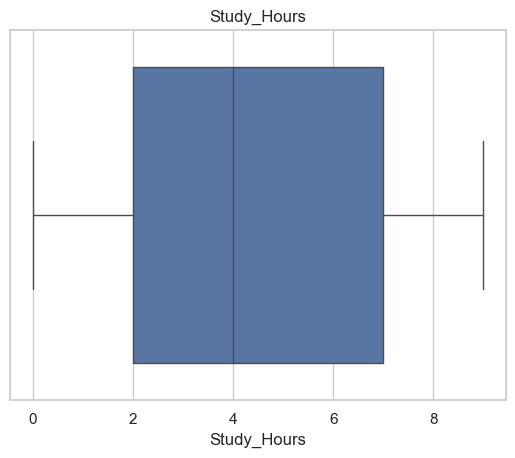

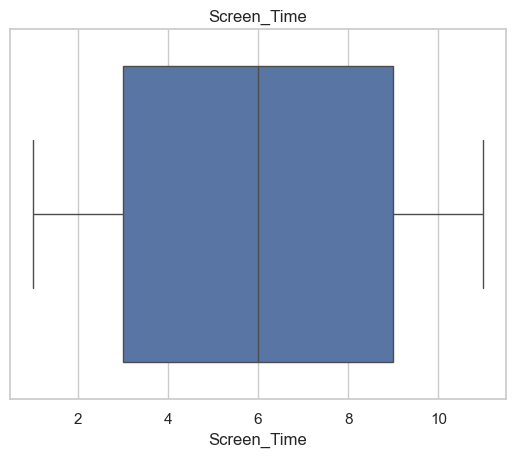

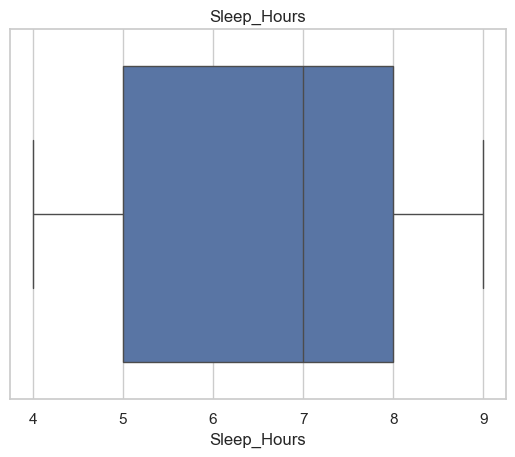

In [158]:
#CEK OUTLIER (SEDERHANA)
for col in ["Study_Hours", "Screen_Time", "Sleep_Hours"]:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

# 5. EXPLORATORY DATA ANALYSIS (EDA) (lanjut fahirrrr)

🔑 Key Findings:
- Dataset menunjukkan ketidakseimbangan kelas, dengan kategori High stress hanya sekitar 10%
- Screen time memiliki hubungan paling jelas dengan tingkat stress
- Mahasiswa dengan stress tinggi memiliki screen time paling tinggi
- Durasi tidur berbanding terbalik dengan stress
- Study hours tidak menunjukkan pengaruh signifikan terhadap stress
- Korelasi linear antar variabel relatif lemah, menunjukkan kemungkinan hubungan non-linear

## Distribusi Target

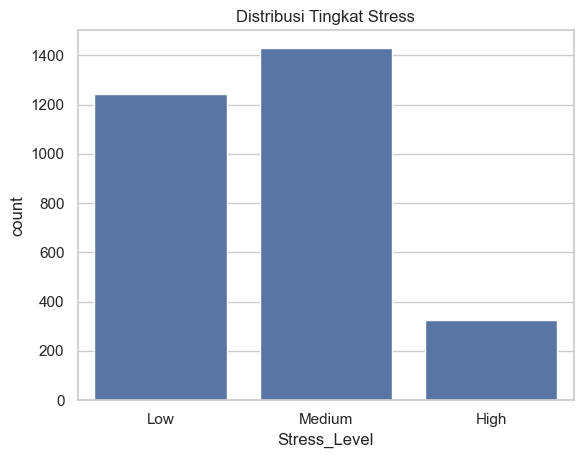

In [159]:
order = ["Low","Medium","High"]

sns.countplot(x="Stress_Level", data=df, order=order)
plt.title("Distribusi Tingkat Stress")
plt.show()

## Correlation

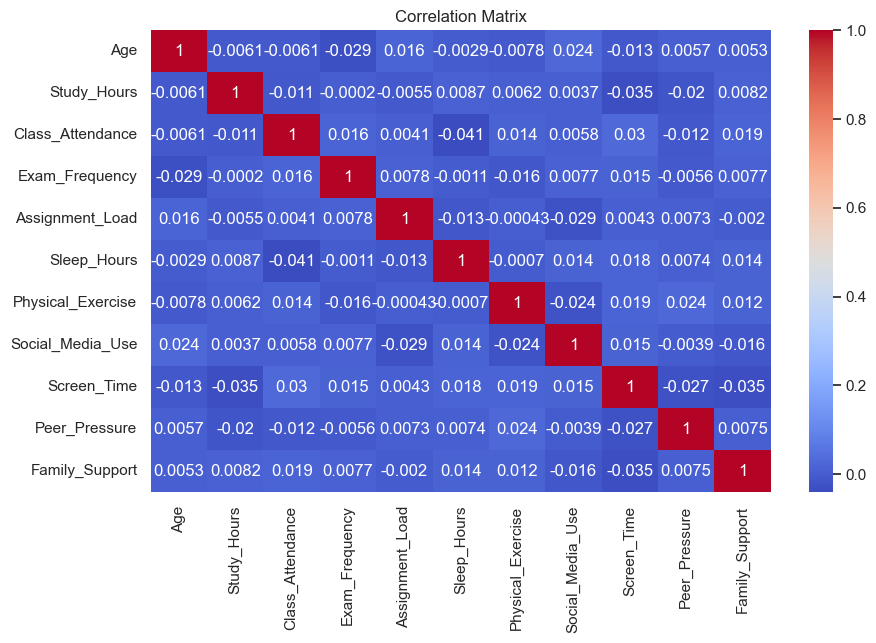

In [160]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [180]:
corr = df.corr(numeric_only=True)["Screen_Time"].sort_values(ascending=False)
print(corr)

Screen_Time          1.000000
Screen_to_Sleep      0.891354
Sleep_Surplus        0.040229
Class_Attendance     0.029559
Physical_Exercise    0.019223
Sleep_Hours          0.018414
Exam_Frequency       0.014956
Social_Media_Use     0.014897
Pressure_Index       0.005704
Assignment_Load      0.004322
Sleep_Deficit       -0.000457
Age                 -0.012583
Peer_Pressure       -0.026959
Family_Support      -0.034991
Study_Hours         -0.035367
Activity_Balance    -0.399946
Study_to_Screen     -0.588055
Name: Screen_Time, dtype: float64


In [181]:
corr = df.corr(numeric_only=True)["Sleep_Hours"].sort_values()
print(corr)

Sleep_Deficit       -0.928694
Screen_to_Sleep     -0.376896
Class_Attendance    -0.041286
Assignment_Load     -0.013046
Activity_Balance    -0.006630
Pressure_Index      -0.004723
Age                 -0.002921
Exam_Frequency      -0.001063
Physical_Exercise   -0.000697
Study_to_Screen      0.001579
Peer_Pressure        0.007423
Study_Hours          0.008678
Social_Media_Use     0.013908
Family_Support       0.014076
Screen_Time          0.018414
Sleep_Surplus        0.831820
Sleep_Hours          1.000000
Name: Sleep_Hours, dtype: float64


## Sleep vs Stress

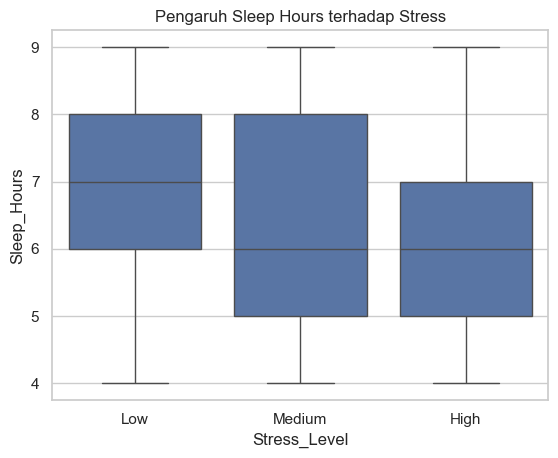

In [161]:
sns.boxplot(x="Stress_Level", y="Sleep_Hours", data=df, order=order)
plt.title("Pengaruh Sleep Hours terhadap Stress")
plt.show()

In [162]:
df.groupby("Stress_Level")["Sleep_Hours"].mean()

Stress_Level
High      5.880368
Low       6.897023
Medium    6.336364
Name: Sleep_Hours, dtype: float64

## Screen Time vs Stress

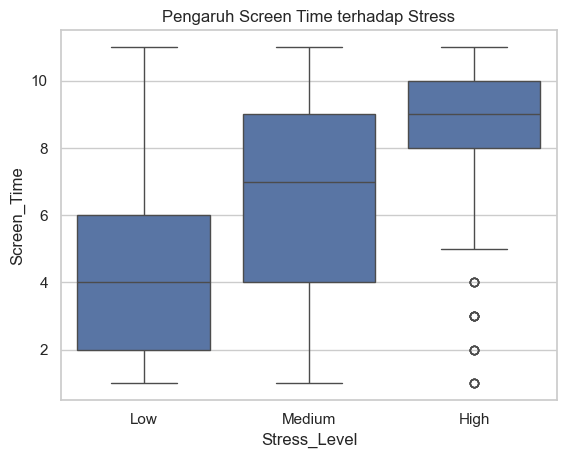

In [163]:
sns.boxplot(x="Stress_Level", y="Screen_Time", data=df, order=order)
plt.title("Pengaruh Screen Time terhadap Stress")
plt.show()

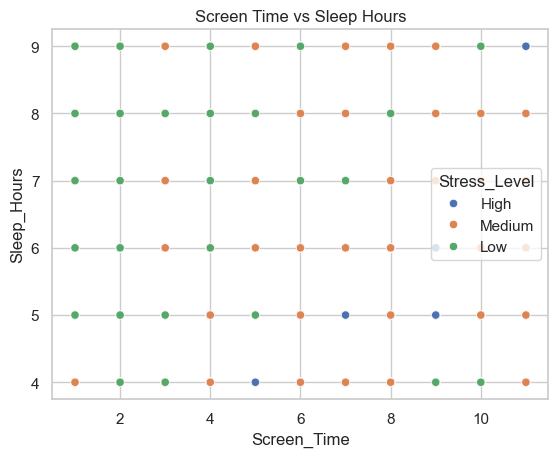

In [185]:
sns.scatterplot(x="Screen_Time", y="Sleep_Hours", hue="Stress_Level", data=df)
plt.title("Screen Time vs Sleep Hours")
plt.show()

## Study Hours vs Stress

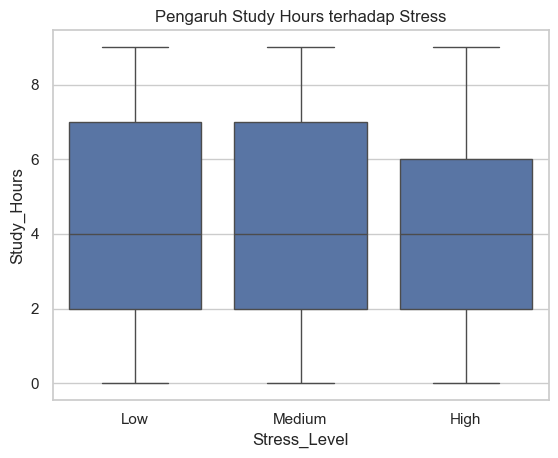

In [164]:
sns.boxplot(x="Stress_Level", y="Study_Hours", data=df, order=order)
plt.title("Pengaruh Study Hours terhadap Stress")
plt.show()

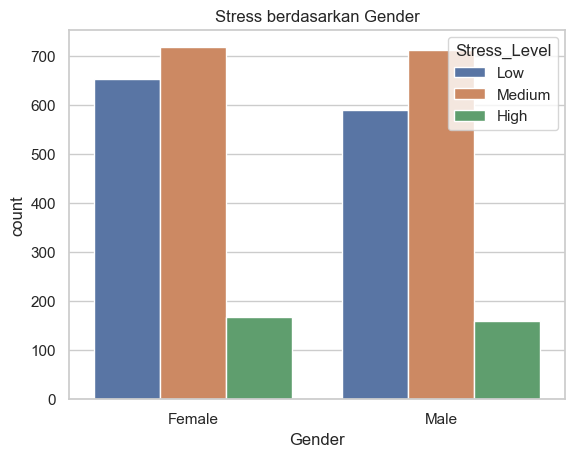

In [165]:
sns.countplot(x="Gender", hue="Stress_Level", data=df, hue_order=order)
plt.title("Stress berdasarkan Gender")
plt.show()

## Tuition vs Stress 

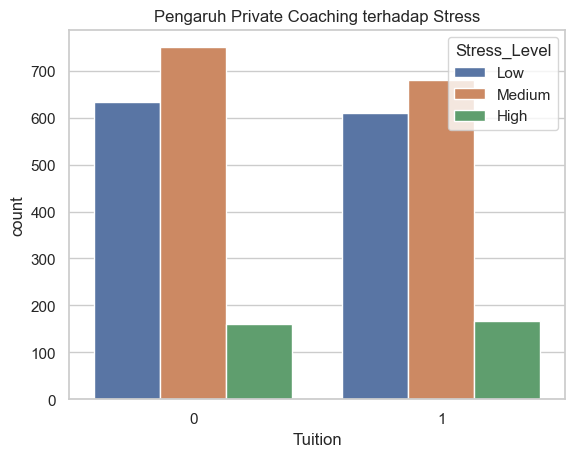

In [166]:
sns.countplot(x="Tuition", hue="Stress_Level", data=df, hue_order=order)
plt.title("Pengaruh Private Coaching terhadap Stress")
plt.show()

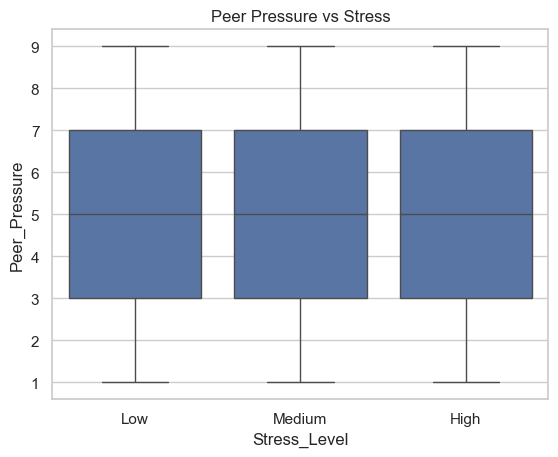

In [186]:
sns.boxplot(x="Stress_Level", y="Peer_Pressure", data=df, order=order)
plt.title("Peer Pressure vs Stress")
plt.show()

In [183]:
df["Stress_Level"].value_counts(normalize=True)*100

Stress_Level
Medium    47.682561
Low       41.447149
High      10.870290
Name: proportion, dtype: float64

In [184]:
df.groupby("Stress_Level")[[
    "Screen_Time",
    "Sleep_Hours",
    "Study_Hours",
    "Peer_Pressure"
]].mean().round(2)

,Screen_Time,Sleep_Hours,Study_Hours,Peer_Pressure
Stress_Level,,,,
High,8.65,5.88,4.29,4.83
Low,4.37,6.90,4.51,5.00
Medium,6.64,6.34,4.51,5.01


# 6. FEATURE ENGINEERING

In [168]:
df["Sleep_Deficit"] = (7 - df["Sleep_Hours"]).clip(lower=0)
df["Sleep_Surplus"] = (df["Sleep_Hours"] - 7).clip(lower=0)

df["Screen_to_Sleep"] = df["Screen_Time"] / (df["Sleep_Hours"] + 1)

df.head()

,Age,Gender,Study_Hours,Class_Attendance,Tuition,Exam_Frequency,Assignment_Load,Sleep_Hours,Physical_Exercise,Social_Media_Use,Screen_Time,Family_Income_Level,Peer_Pressure,Family_Support,University_Type,Stress_Level,Sleep_Deficit,Sleep_Surplus,Screen_to_Sleep
0,24,Female,8,43,1,6,8,5,1,6,8,Medium,3,7,National University,High,2,0,1.333333
1,21,Female,4,56,1,3,6,5,1,7,9,Low,2,5,Private University,Medium,2,0,1.500000
2,23,Female,4,46,0,8,6,8,0,5,6,Medium,8,6,Private University,Medium,0,1,0.666667
3,20,Male,8,46,0,5,1,6,1,0,7,Medium,5,6,National University,Low,1,0,1.000000
4,19,Male,2,95,0,5,2,7,0,3,6,Low,2,6,National University,Low,0,0,0.750000


In [169]:
(df.select_dtypes(include="number") < 0).sum()

Age                  0
Study_Hours          0
Class_Attendance     0
Exam_Frequency       0
Assignment_Load      0
Sleep_Hours          0
Physical_Exercise    0
Social_Media_Use     0
Screen_Time          0
Peer_Pressure        0
Family_Support       0
Sleep_Deficit        0
Sleep_Surplus        0
Screen_to_Sleep      0
dtype: int64

In [170]:
# Productivity vs distraction
df["Study_to_Screen"] = df["Study_Hours"] / (df["Screen_Time"] + 1)

# Pressure vs support
df["Pressure_Index"] = df["Peer_Pressure"] - df["Family_Support"]

# Lifestyle balance
df["Activity_Balance"] = df["Physical_Exercise"] / (df["Screen_Time"] + 1)

In [171]:
print("Check negative:")
print((df.select_dtypes(include="number") < 0).sum())

import numpy as np
print("Check infinity:")
print(np.isinf(df.select_dtypes(include="number")).sum())

print("Check NaN:")
print(df.isnull().sum())

Check negative:
Age                     0
Study_Hours             0
Class_Attendance        0
Exam_Frequency          0
Assignment_Load         0
Sleep_Hours             0
Physical_Exercise       0
Social_Media_Use        0
Screen_Time             0
Peer_Pressure           0
Family_Support          0
Sleep_Deficit           0
Sleep_Surplus           0
Screen_to_Sleep         0
Study_to_Screen         0
Pressure_Index       1327
Activity_Balance        0
dtype: int64
Check infinity:
Age                  0
Study_Hours          0
Class_Attendance     0
Exam_Frequency       0
Assignment_Load      0
Sleep_Hours          0
Physical_Exercise    0
Social_Media_Use     0
Screen_Time          0
Peer_Pressure        0
Family_Support       0
Sleep_Deficit        0
Sleep_Surplus        0
Screen_to_Sleep      0
Study_to_Screen      0
Pressure_Index       0
Activity_Balance     0
dtype: int64
Check NaN:
Age                    0
Gender                 0
Study_Hours            0
Class_Attendance       

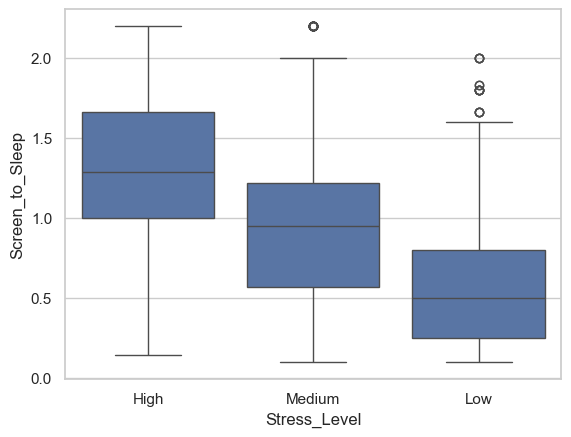

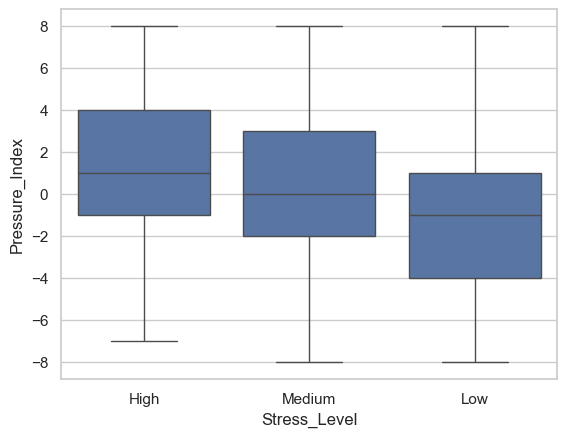

In [172]:
sns.boxplot(x="Stress_Level", y="Screen_to_Sleep", data=df)
plt.show()

sns.boxplot(x="Stress_Level", y="Pressure_Index", data=df)
plt.show()

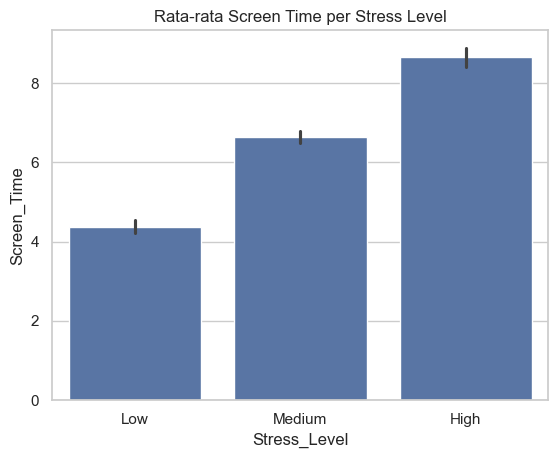

In [173]:
sns.barplot(x="Stress_Level", y="Screen_Time", data=df, order=order)
plt.title("Rata-rata Screen Time per Stress Level")
plt.show()

In [174]:
new_features = [
    "Sleep_Deficit",
    "Sleep_Surplus",
    "Screen_to_Sleep",
    "Study_to_Screen",
    "Pressure_Index",
    "Activity_Balance"
]

df[new_features].describe()

,Sleep_Deficit,Sleep_Surplus,Screen_to_Sleep,Study_to_Screen,Pressure_Index,Activity_Balance
count,2999.000000,2999.000000,2999.000000,2999.000000,2999.000000,2999.000000
mean,0.979993,0.499166,0.829048,0.886858,-0.044015,0.093819
std,1.136865,0.759584,0.497684,0.879876,3.618212,0.130467
min,0.000000,0.000000,0.100000,0.000000,-8.000000,0.000000
25%,0.000000,0.000000,0.428571,0.285714,-3.000000,0.000000
50%,0.000000,0.000000,0.800000,0.666667,0.000000,0.000000
75%,2.000000,1.000000,1.166667,1.142857,3.000000,0.142857
max,3.000000,2.000000,2.200000,4.500000,8.000000,0.500000


In [175]:
print(df.dtypes)

Age                       int64
Gender                   object
Study_Hours               int64
Class_Attendance          int64
Tuition                category
Exam_Frequency            int64
Assignment_Load           int64
Sleep_Hours               int64
Physical_Exercise         int64
Social_Media_Use          int64
Screen_Time               int64
Family_Income_Level    category
Peer_Pressure             int64
Family_Support            int64
University_Type          object
Stress_Level             object
Sleep_Deficit             int64
Sleep_Surplus             int64
Screen_to_Sleep         float64
Study_to_Screen         float64
Pressure_Index            int64
Activity_Balance        float64
dtype: object


In [176]:
new_features = [
    "Screen_to_Sleep",
    "Study_to_Screen",
    "Pressure_Index",
    "Activity_Balance"
]

df[new_features].describe()

,Screen_to_Sleep,Study_to_Screen,Pressure_Index,Activity_Balance
count,2999.000000,2999.000000,2999.000000,2999.000000
mean,0.829048,0.886858,-0.044015,0.093819
std,0.497684,0.879876,3.618212,0.130467
min,0.100000,0.000000,-8.000000,0.000000
25%,0.428571,0.285714,-3.000000,0.000000
50%,0.800000,0.666667,0.000000,0.000000
75%,1.166667,1.142857,3.000000,0.142857
max,2.200000,4.500000,8.000000,0.500000


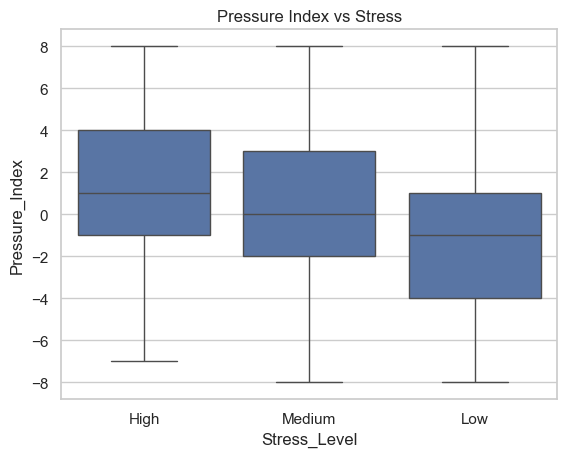

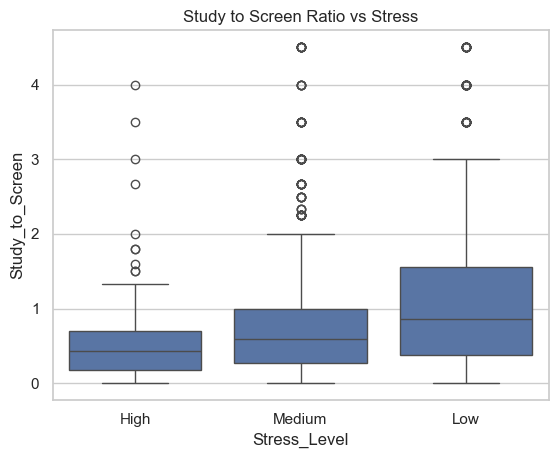

In [177]:
sns.boxplot(x="Stress_Level", y="Pressure_Index", data=df)
plt.title("Pressure Index vs Stress")
plt.show()

sns.boxplot(x="Stress_Level", y="Study_to_Screen", data=df)
plt.title("Study to Screen Ratio vs Stress")
plt.show()

In [178]:
df.groupby("Stress_Level")[[
    "Sleep_Hours",
    "Screen_Time",
    "Study_Hours"
]].mean().round(2)

,Sleep_Hours,Screen_Time,Study_Hours
Stress_Level,,,
High,5.88,8.65,4.29
Low,6.90,4.37,4.51
Medium,6.34,6.64,4.51


# 7. PREPARATION FOR MODEL

In [179]:
X = df.drop(columns=["Stress_Level"])
y = df["Stress_Level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 8. PREPROCESSING

# 9. MODELING (Anak AI)

# 10. EVALUATION (Anak AI)